# TO:DO 
## check: https://www.nature.com/articles/nature17995 cumulative effect of mutations

Fitness score is cholesterol accumulation.\
This is the article for this dataset: https://pubmed.ncbi.nlm.nih.gov/35190686/ \
Can I predict severity scores of real patients using the model trained on fitness scores?

## Why genomic model?

* We lose information if we use protein sequences.
* 3 **synonomous** substitutions had deleterious effect on function score
* 10 positions had different SPE Classification depending on nucleotide.

## Plan

1. Train model on HEK dataset.
2. Show model generalization across different parts of the protein
3. Show model generalization on different cell line (make sure positions are different and there is no data leakage!)
4. Use fitness score model to predict severity scores from genome??? But sounds very cool, need to think how to bridge these two! Maybe I can fine tune foundation model on dataset and then produce embeddings and then embeddigns x learnable weight for severity score.

## Bimodal distribution 
1. try first simple regression if quality is poor
2. then mixture of experts: split samples to 2 groups and then train separate regressors for each group.

## Embeddings

If you want to use all your data for embeddings eventually (e.g. for a final production model), the workflow is:

Do train/test split
Fine-tune on train, evaluate on test to get honest performance metrics
Once satisfied, retrain final model on full dataset — but you report the performance from step 2, not from the full-data model

Why I plan to use RNA and I don't want to use DNA - Length of DNA is 62119

Clinvar as additional validation

In [4]:
import numpy as np

mut_seq = np.load('output/mut_seq_DNA_forward.npy')
mut_seq

array(['ATGGACTGATAAAAGCTCACAGGAAAAACATTTTATCTACTGTTCCACATTTGCTTTTGCTTTTTTTTTAGATACATTTTAACAGCTTTAAGAATCTCCTTCCCAGGCTGTCTGGCTTCTTAGAAGGCATGTGATAATCTGTTTCAGTGAGAGGAAAGAGAAAAACCACAGATAAGCGCATACCACAATTGGTCTCATCCAGTCCTTTAGCAGAAGTGGAGAATAGGAGTTTTTGAAGAAGCGAAACAAACAGCTCTCTGAGGCCTGGACGCTTGTTCCATCTTCAGCACCTCTGACACAGCAAAAGATGTCTAGCCGATTTTTCTGAGGGGACAGAGGGAAACAAAGGTTATACCCGCTAGCTGCTTCCTCTAGATTCTAGACTCAAATTAAATAGACTATAATCCTGGCACCAACTTACCTCTTGACGTTTAATGTCTAACCCCAAGAGACTCACGAAACAGGTAATCTGCAGAAGAAAGTCAATGAAGACTGCCAATCCCGCAAAGAGAGAGAAGGTGTGCACGGCTGGCATCACGGACAATGCTCCTGTCGGGGAGAGAAGGGCTCTGCGTCACTTCTGTTTACAGCCGGGGGCTCTCTGCAGGTCTTATGTTCATGTGCATGTACAGATACAAGGAGCCAGCACAGGCCAAACGCATGAGAAGGCATGCTGCGGCTGGACATTACACCAGAAGTGGGACAGGAGGTGATAAGCCAGTGCTTTTCAAAGCACACTCAGCACCAGACCATTTGGGAAGCCCCATCCTAGTTATGACAGGAATTCAACCCCAATTCTACTATACTCAGGTTCACAGCAAATTCACACACATTAAAATTTGAGAACCACTAATACAGGCCATTTCTTATAGTACTTTCTGTGCTTCACTGTAAGAAATGGACAGTATTTTCCATTTATTACATCAACACTACTAGCCTCCCAGTTTAGTTAAGAGGTAATCTACAATCGAGTGAGGATCAAAGGCATGAGG

In [8]:
import pandas as pd
pd.set_option("display.max_columns", None)

df = pd.read_csv('results_Evo2_7B_reverse/metrics.csv')
df[df['test_corr'] == df['test_corr'].max()]

,layer,model_arch,pooling,emb_type,strand,model,hyperparams,train_corr,train_corr_std,train_mse,train_mse_std,train_mae,train_mae_std,val_corr,val_corr_std,val_mse,val_mse_std,val_mae,val_mae_std,test_corr,test_corr_std,test_mse,test_mse_std,test_mae,test_mae_std
178,L27,Evo2,average,delta,reverse,SVR,"C=1.0, kernel=rbf",0.910488,0.00596,0.020522,0.001149,0.107991,0.001733,0.713503,0.010563,0.074113,0.002002,0.209238,0.003231,0.736484,0.015311,0.068657,0.002895,0.200615,0.003956


In [28]:
parameters = ['7B', '40B', '1B']
strands = ['reverse', 'forward']

dfs = []
configs = []
try:
    for parameter in parameters:
        for strand in strands:
            path = f'results_Evo2_{parameter}_{strand}/metrics.csv'
            df = pd.read_csv(path)
            res = df[df['test_corr'] == df['test_corr'].max()]
            dfs.append(res)
            configs.append(f'{parameter}_{strand}')
except FileNotFoundError:
    print(f"{path} not found.")

In [29]:
print(configs)

['7B_reverse', '7B_forward', '40B_reverse', '40B_forward', '1B_reverse', '1B_forward']


In [ ]:
df = pd.concat(dfs, ignore_index=True)
df

,layer,model_arch,pooling,emb_type,strand,model,hyperparams,train_corr,train_corr_std,train_mse,train_mse_std,train_mae,train_mae_std,val_corr,val_corr_std,val_mse,val_mse_std,val_mae,val_mae_std,test_corr,test_corr_std,test_mse,test_mse_std,test_mae,test_mae_std
0,L27,Evo2,average,delta,reverse,SVR,"C=1.0, kernel=rbf",0.910488,5.960460e-03,2.052194e-02,1.149264e-03,0.107991,1.732784e-03,0.713503,0.010563,0.074113,0.002002,0.209238,0.003231,0.736484,0.015311,0.068657,0.002895,0.200615,0.003956
1,L27,Evo2,average,delta,forward,SVR,"C=1.0, kernel=rbf",0.927475,1.016562e-03,1.665107e-02,7.493225e-04,0.099335,1.182290e-03,0.738663,0.013611,0.069866,0.002066,0.205065,0.004080,0.748143,0.017983,0.066316,0.004859,0.195454,0.006662
2,L43,Evo2,last,concat,reverse,kNN,"n_neighbors=5, weights=distance",1.000000,1.414739e-08,8.277768e-12,6.379542e-13,0.000001,5.180247e-08,0.318489,0.038157,0.161932,0.006984,0.322212,0.008158,0.329627,0.067999,0.158831,0.013510,0.312512,0.009950
3,L47,Evo2,average,concat,forward,kNN,"n_neighbors=5, weights=distance",1.000000,1.410198e-08,1.002477e-11,2.336772e-12,0.000002,1.542971e-07,0.259105,0.039641,0.174840,0.006938,0.332217,0.008291,0.330919,0.090353,0.157942,0.019942,0.310275,0.021874
4,L13,Evo2,average,delta,reverse,SVR,"C=1.0, kernel=rbf",0.990700,1.848083e-03,1.050320e-02,1.134194e-04,0.098076,2.127847e-04,0.313076,0.037554,0.141327,0.003376,0.335189,0.004400,0.353205,0.084287,0.136258,0.009447,0.326831,0.011817
5,L13,Evo2,average,delta,forward,SVR,"C=1.0, kernel=rbf",0.993030,1.403093e-03,9.849432e-03,2.225482e-04,0.096399,7.567709e-04,0.339151,0.048548,0.141007,0.004824,0.333737,0.005678,0.426922,0.091258,0.130600,0.008558,0.318631,0.012582


In [9]:
df = pd.read_csv('results_Evo2_7B_forward/metrics.csv')
df[df['test_corr'] == df['test_corr'].max()]

,layer,model_arch,pooling,emb_type,strand,model,hyperparams,train_corr,train_corr_std,train_mse,train_mse_std,train_mae,train_mae_std,val_corr,val_corr_std,val_mse,val_mse_std,val_mae,val_mae_std,test_corr,test_corr_std,test_mse,test_mse_std,test_mae,test_mae_std
178,L27,Evo2,average,delta,forward,SVR,"C=1.0, kernel=rbf",0.927475,0.001017,0.016651,0.000749,0.099335,0.001182,0.738663,0.013611,0.069866,0.002066,0.205065,0.00408,0.748143,0.017983,0.066316,0.004859,0.195454,0.006662


In [2]:
import glob
from pathlib import Path

emb_dir = "emb_1B"
strand = "forward"

if not hasattr(emb_dir, "glob"):
    emb_dir = Path(emb_dir)
ref_files = sorted(emb_dir.glob(f"ref_seq_*{strand}*.npy"))
ref_files

[PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L10_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L10_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L12_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L12_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L13_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L13_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L14_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L14_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L15_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L15_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L16_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L16_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L17_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L17_last_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_Evo2_1B_L18_average_forward.npy'),
 PosixPath('emb_1B/ref_seq_DNA_

In [1]:
import pandas as pd

# CDS is a position within coding sequence
df = pd.read_excel('data/NPC1_mut_fitness_scores.xlsx', header=1)
df.head(2)

,Protein Annotation,Wild type Base,Edited Base,CDS,Consequence,SPE Classification,Function Score,id,start,end,reference_base,alternate_base,refseq_id,Clinvar_SIG,CADD_phred,Unadjusted Function Score
0,L1027L,T,A,3081,synonymous,Functional,0.954726,chr18-23536836-23536837-A-T,23536836,23536837,A,T,NPC1:NM_000271:exon21:c.T3081A:p.L1027L:Select,NaN,NaN,0.188709
1,L1027L,T,C,3081,synonymous,Functional,0.999139,chr18-23536836-23536837-A-G,23536836,23536837,A,G,NPC1:NM_000271:exon21:c.T3081C:p.L1027L:Select,NaN,NaN,0.008803


In [2]:
df.shape

(978, 16)

In [40]:
df[df['Protein Annotation'] == 'I1061T']

,Protein Annotation,Wild type Base,Edited Base,CDS,Consequence,SPE Classification,Function Score,id,start,end,reference_base,alternate_base,refseq_id,Clinvar_SIG,CADD_phred,Unadjusted Function Score
58,I1061T,T,C,3182,missense,Deleterious,0.07647,chr18-23536735-23536736-A-G,23536735,23536736,A,G,NPC1:NM_000271:exon21:c.T3182C:p.I1061T:Select,Pathogenic,26.5,2.839273


In [24]:
df[df['Consequence'] == "synonymous"]

,Protein Annotation,Wild type Base,Edited Base,CDS,Consequence,SPE Classification,Function Score,id,start,end,reference_base,alternate_base,refseq_id,Clinvar_SIG,CADD_phred,Unadjusted Function Score
0,L1027L,T,A,3081,synonymous,Functional,0.954726,chr18-23536836-23536837-A-T,23536836,23536837,A,T,NPC1:NM_000271:exon21:c.T3081A:p.L1027L:Select,NaN,NaN,0.188709
1,L1027L,T,C,3081,synonymous,Functional,0.999139,chr18-23536836-23536837-A-G,23536836,23536837,A,G,NPC1:NM_000271:exon21:c.T3081C:p.L1027L:Select,NaN,NaN,0.008803
2,L1027L,T,G,3081,synonymous,Functional,0.963492,chr18-23536836-23536837-A-C,23536836,23536837,A,C,NPC1:NM_000271:exon21:c.T3081G:p.L1027L:Select,NaN,NaN,0.145510
9,G1028G,C,A,3084,synonymous,Functional,0.977158,chr18-23536833-23536834-G-T,23536833,23536834,G,T,NPC1:NM_000271:exon21:c.C3084A:p.G1028G:Select,NaN,NaN,0.098157
10,G1028G,C,G,3084,synonymous,Functional,0.965817,chr18-23536833-23536834-G-C,23536833,23536834,G,C,NPC1:NM_000271:exon21:c.C3084G:p.G1028G:Select,NaN,NaN,0.137536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,S918S,C,T,2754,synonymous,Functional,0.982275,chr18-23539851-23539852-G-A,23539851,23539852,G,A,NPC1:NM_000271:exon18:c.C2754T:p.S918S:Select,NaN,NaN,0.051688
968,L919L,C,T,2755,synonymous,Functional,1.013506,chr18-23539850-23539851-G-A,23539850,23539851,G,A,NPC1:NM_000271:exon18:c.C2755T:p.L919L:Select,NaN,11.36,-0.036948
972,L919L,G,A,2757,synonymous,Functional,1.008036,chr18-23539848-23539849-C-T,23539848,23539849,C,T,NPC1:NM_000271:exon18:c.G2757A:p.L919L:Select,NaN,NaN,-0.030856
973,L919L,G,C,2757,synonymous,Functional,1.008759,chr18-23539848-23539849-C-G,23539848,23539849,C,G,NPC1:NM_000271:exon18:c.G2757C:p.L919L:Select,NaN,NaN,-0.031451


<Axes: >

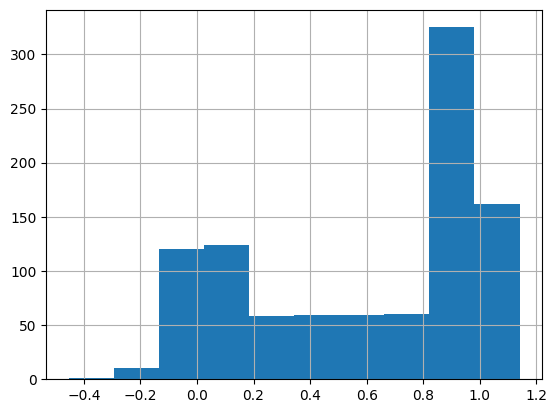

In [23]:
df['Function Score'].hist()

In [22]:
df.shape

(978, 16)

I1061T (wild type T -> edited base C), position is end (23536736) NC_000018.10:g.23536736A>G \
Reference base - reference base in the DNA (reverse strand)!\
Wild type base - reference base in the RNA\
Check here: df[~df['Clinvar_SIG'].isna()] - first one!

In [15]:
numbers = [int(x[1:-1]) if isinstance(x,str) else x
           for x in df['Protein Annotation'].unique()]
min(numbers), max(numbers)

(347, 1190)

In [29]:
print(f"The size of the dataframe {df.shape}")


print(f"There are {df[df['Consequence'] == 'splice region'].shape[0]} variants in the splice region. They will be excluded from the dataset for modeling, as we will focus on coding sequence.")
df = df[~(df['Consequence'] == 'splice region')]
sample_number = df.shape[0]
#df.to_csv('output/df_preprocessed.csv')
df['CDS'].min(), df['CDS'].max()

The size of the dataframe (978, 16)
There are 9 variants in the splice region. They will be excluded from the dataset for modeling, as we will focus on coding sequence.


(1040, 3568)

In [21]:
import requests
from Bio import SeqIO
from io import StringIO
import numpy as np

url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000018.10&rettype=fasta&retmode=text"
response = requests.get(url)

record_DNA  = SeqIO.read(StringIO(response.text), "fasta")
seq = record_DNA.seq

In [44]:
end_pos = 23536837
ind = end_pos - 1
print(f"Length of DNA NPC1: {len(seq)} nucleotides")
print(f"Genomic position: {ind}")
print(f"Reference nucleotide: {seq[ind]}")


window_size = 8192

def mutate_seq(seq, pos, new_base):
    ind = pos - 1
    assert df['reference_base'][i] == seq[ind], f"Mismatch at ind={ind}"

    ref_seq = str(seq)
    start = max(0, ind - window_size//2)
    end = min(window_size//2+1 + ind, len(ref_seq))
    ref_seq = seq[start:end]
    mut_seq = seq[start:ind] + new_base + seq[ind+1:end] 
    return ref_seq, mut_seq

new_seqs = []
ref_seqs = []

for i in (df.index):
    pos = df['end'][i]
    new_base = df['alternate_base'][i]
    new_seq, ref_seq = mutate_seq(seq, pos, new_base)
    new_seqs.append(new_seq)
    ref_seqs.append(ref_seq)

new_seqs, ref_seqs = np.array(new_seqs), np.array(ref_seqs)
assert sample_number == new_seqs.shape[0] == ref_seqs.shape[0]

new_seqs_rc = np.array([str(Seq(''.join(s)).reverse_complement()) for s in new_seqs])
ref_seqs_rc = np.array([str(Seq(''.join(s)).reverse_complement()) for s in ref_seqs])

np.save("output/mut_seq_DNA.npy", new_seqs_rc)
np.save("output/ref_seq_DNA.npy", ref_seqs_rc)


Length of DNA NPC1: 80373285 nucleotides
Genomic position: 23536836
Reference nucleotide: A


In [50]:
len(df['Protein Annotation'].unique()), len(df)

(769, 969)

In [48]:
print(f'Reference, SNV 0: ...{new_seq[4082:4112]}...')
print(f'Variant, SNV 0:   ...{ref_seq[4082:4112]}...')

Reference, SNV 0: ...AAATATCTGCTGCACCAGGGAATCATTGTT...
Variant, SNV 0:   ...AAATATCTGCTGCAACAGGGAATCATTGTT...
